In [1]:
!rm -rf /kaggle/working/*


Using device: cuda
IMPROVED MAZE-SOLVING DIFFUSION MODEL

1. Creating dataset (50,000 mazes)...

2. Initializing model...
   Parameters: 7,219,969

3. Training for 50 epochs...


   Epoch 1/20 - Loss: 0.062292


   Epoch 2/20 - Loss: 0.017019


   Epoch 3/20 - Loss: 0.011711


   Epoch 4/20 - Loss: 0.009387


...

   Epoch 17/20 - Loss: 0.002704


   Epoch 18/20 - Loss: 0.002268


   Epoch 19/20 - Loss: 0.002462


   Epoch 20/20 - Loss: 0.002115
   → Saved checkpoint



   Training complete!


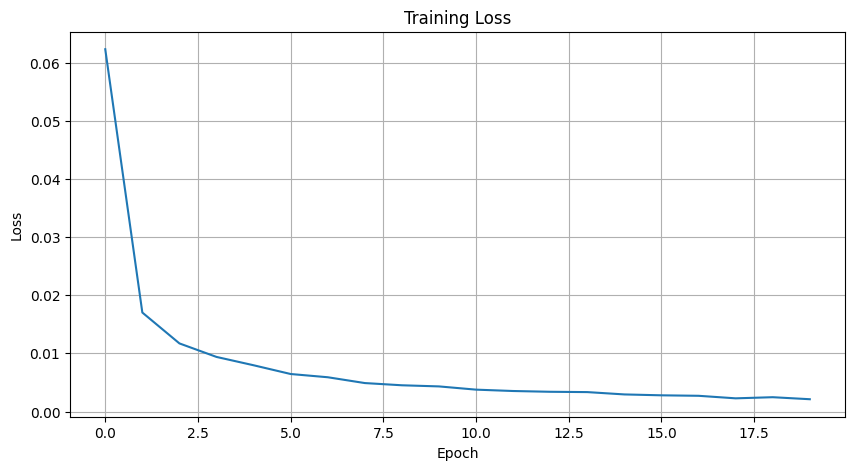


4. Testing maze solving...

   Solving maze 1...


   GT path: 223, Extracted: 223


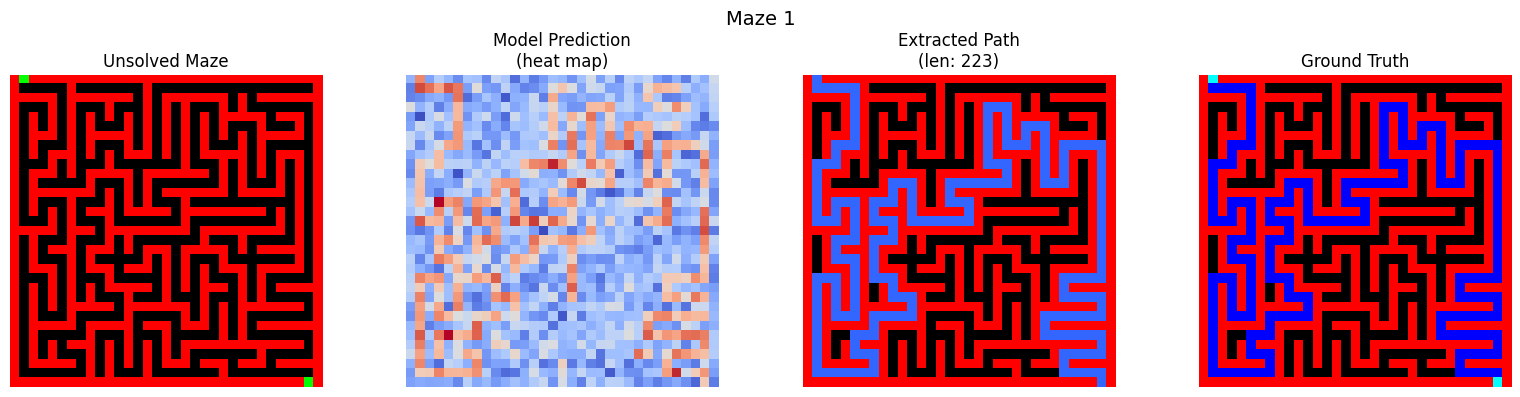


   Solving maze 2...


   GT path: 183, Extracted: 183


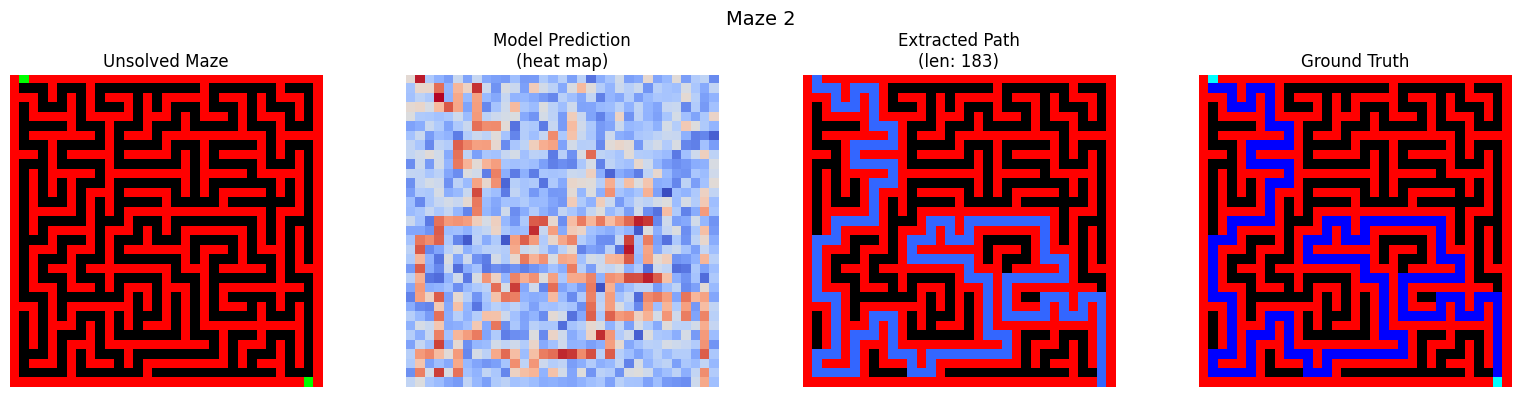


   Solving maze 3...


   GT path: 331, Extracted: 331


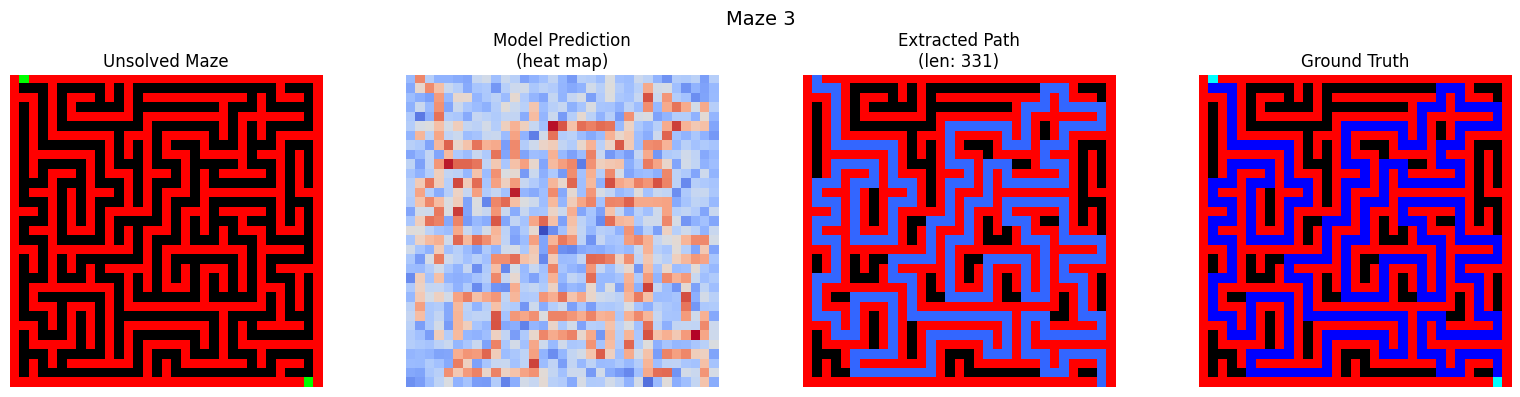


   Solving maze 4...


   GT path: 187, Extracted: 187


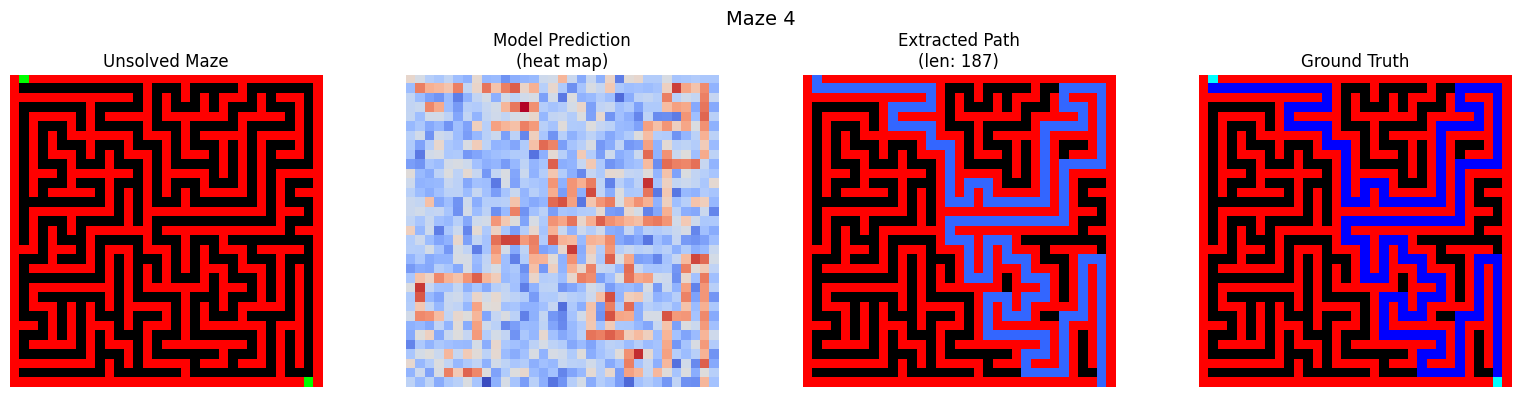


Done!


In [2]:
# ==============================================================================
# IMPROVED MAZE-SOLVING DIFFUSION MODEL
# ==============================================================================
# Key improvements:
# 1. More training (50 epochs, bigger dataset)
# 2. Better sampling with proper thresholding
# 3. Post-processing: extract connected path from noisy prediction
# 4. Uses prediction as "cost map" for guided pathfinding
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from typing import Tuple, List
import random
from tqdm import tqdm
import math
import heapq

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

IMAGE_SIZE = 33
NUM_CHANNELS = 4


# ==============================================================================
# MAZE GENERATION
# ==============================================================================

class MazeGenerator:
    def __init__(self, width: int, height: int):
        self.width = width if width % 2 == 1 else width - 1
        self.height = height if height % 2 == 1 else height - 1
    
    def generate(self) -> np.ndarray:
        maze = np.ones((self.height, self.width), dtype=int)
        start_y, start_x = 1, 1
        maze[start_y, start_x] = 0
        
        stack = [(start_y, start_x)]
        directions = [(-2, 0), (0, 2), (2, 0), (0, -2)]
        
        while stack:
            current_y, current_x = stack[-1]
            random.shuffle(directions)
            
            found = False
            for dy, dx in directions:
                ny, nx = current_y + dy, current_x + dx
                if 1 <= ny < self.height - 1 and 1 <= nx < self.width - 1:
                    if maze[ny, nx] == 1:
                        wall_y, wall_x = current_y + dy // 2, current_x + dx // 2
                        maze[wall_y, wall_x] = 0
                        maze[ny, nx] = 0
                        stack.append((ny, nx))
                        found = True
                        break
            
            if not found:
                stack.pop()
        
        maze[0, 1] = 0
        for x in range(self.width - 2, 0, -1):
            if maze[self.height - 2, x] == 0:
                maze[self.height - 1, x] = 0
                break
        
        return maze
    
    def solve_bfs(self, maze: np.ndarray) -> List[Tuple[int, int]]:
        height, width = maze.shape
        
        start = None
        for x in range(width):
            if maze[0, x] == 0:
                start = (0, x)
                break
        
        end = None
        for x in range(width - 1, -1, -1):
            if maze[height - 1, x] == 0:
                end = (height - 1, x)
                break
        
        if start is None or end is None:
            return []
        
        queue = deque([start])
        visited = {start: None}
        directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        
        while queue:
            y, x = queue.popleft()
            if (y, x) == end:
                path = []
                current = end
                while current is not None:
                    path.append(current)
                    current = visited[current]
                return path[::-1]
            
            for dy, dx in directions:
                ny, nx = y + dy, x + dx
                if (0 <= ny < height and 0 <= nx < width and 
                    maze[ny, nx] == 0 and (ny, nx) not in visited):
                    visited[(ny, nx)] = (y, x)
                    queue.append((ny, nx))
        
        return []
    
    def render_solved_maze(self, maze: np.ndarray, path: List[Tuple[int, int]]) -> np.ndarray:
        height, width = maze.shape
        image = np.zeros((4, height, width), dtype=np.float32)
        
        image[0] = maze.astype(np.float32)
        
        if path:
            start_y, start_x = path[0]
            image[1, start_y, start_x] = 1.0
            end_y, end_x = path[-1]
            image[2, end_y, end_x] = 1.0
        
        for y, x in path:
            image[3, y, x] = 1.0
        
        return image


# ==============================================================================
# PATH EXTRACTION FROM PREDICTION (KEY IMPROVEMENT!)
# ==============================================================================

def extract_path_from_prediction(maze: np.ndarray, prediction: np.ndarray, 
                                  start: Tuple[int, int], end: Tuple[int, int]) -> List[Tuple[int, int]]:
    """
    Use A* with the model's prediction as a cost map.
    Lower prediction values = higher cost (model thinks it's NOT the path)
    Higher prediction values = lower cost (model thinks it IS the path)
    """
    height, width = maze.shape
    
    # Create cost map: where prediction is high, cost is low
    # Normalize prediction to [0, 1]
    pred_min, pred_max = prediction.min(), prediction.max()
    if pred_max - pred_min > 0:
        cost_map = 1.0 - (prediction - pred_min) / (pred_max - pred_min)
    else:
        cost_map = np.ones_like(prediction) * 0.5
    
    # A* search
    def heuristic(a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])
    
    open_set = [(0, start)]
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, end)}
    
    directions = [(-1, 0), (0, 1), (1, 0), (0, -1)]
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == end:
            # Reconstruct path
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]
        
        for dy, dx in directions:
            neighbor = (current[0] + dy, current[1] + dx)
            ny, nx = neighbor
            
            # Skip if out of bounds or wall
            if not (0 <= ny < height and 0 <= nx < width):
                continue
            if maze[ny, nx] == 1:
                continue
            
            # Cost = base cost + cost from prediction map
            move_cost = 1.0 + cost_map[ny, nx] * 10  # Weight prediction
            tentative_g = g_score[current] + move_cost
            
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + heuristic(neighbor, end)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))
    
    # Fallback to BFS if A* fails
    return []


def find_start_end(condition: np.ndarray) -> Tuple[Tuple[int, int], Tuple[int, int]]:
    """Find start and end positions from condition tensor."""
    start_channel = condition[1]  # Start channel
    end_channel = condition[2]    # End channel
    
    start_pos = np.unravel_index(np.argmax(start_channel), start_channel.shape)
    end_pos = np.unravel_index(np.argmax(end_channel), end_channel.shape)
    
    return tuple(start_pos), tuple(end_pos)


# ==============================================================================
# DATASET
# ==============================================================================

class MazeSolvingDataset(torch.utils.data.Dataset):
    def __init__(self, size: int, image_size: int = IMAGE_SIZE):
        self.size = size
        self.image_size = image_size
        self.generator = MazeGenerator(image_size, image_size)
    
    def __len__(self):
        return self.size
    
    def __getitem__(self, idx):
        maze = self.generator.generate()
        path = self.generator.solve_bfs(maze)
        solved_maze = self.generator.render_solved_maze(maze, path)
        
        condition = torch.from_numpy(solved_maze[0:3]).float()
        target_path = torch.from_numpy(solved_maze[3:4]).float()
        
        return condition, target_path


# ==============================================================================
# DIFFUSION PROCESS
# ==============================================================================

class ConditionalDiffusionProcess:
    def __init__(self, num_timesteps: int = 1000, beta_start: float = 0.0001, beta_end: float = 0.02):
        self.num_timesteps = num_timesteps
        
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alpha_bars = self.alpha_bars.to(device)
    
    def add_noise(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        
        sqrt_alpha_bar_t = torch.sqrt(self.alpha_bars[t]).view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - self.alpha_bars[t]).view(-1, 1, 1, 1)
        
        return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise
    
    def sample_timesteps(self, batch_size):
        return torch.randint(0, self.num_timesteps, (batch_size,), device=device)
    
    @torch.no_grad()
    def sample(self, model, condition, num_steps=None):
        if num_steps is None:
            num_steps = self.num_timesteps
        
        batch_size = condition.shape[0]
        h, w = condition.shape[2], condition.shape[3]
        
        path = torch.randn(batch_size, 1, h, w, device=device)
        
        timesteps = torch.linspace(self.num_timesteps - 1, 0, num_steps, dtype=torch.long, device=device)
        
        for t in tqdm(timesteps, desc="Denoising", leave=False):
            t_batch = t.expand(batch_size)
            x_input = torch.cat([condition, path], dim=1)
            noise_pred = model(x_input, t_batch)
            
            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]
            beta = self.betas[t]
            
            if t > 0:
                alpha_bar_prev = self.alpha_bars[t - 1]
                noise = torch.randn_like(path)
                sigma = torch.sqrt(beta * (1 - alpha_bar_prev) / (1 - alpha_bar))
            else:
                sigma = 0
                noise = 0
            
            path = (1 / torch.sqrt(alpha)) * (
                path - (beta / torch.sqrt(1 - alpha_bar)) * noise_pred
            ) + sigma * noise
        
        return path  # Return raw prediction (not thresholded)


# ==============================================================================
# U-NET MODEL
# ==============================================================================

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        return torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, up=False, down=False):
        super().__init__()
        self.up = up
        
        if down:
            self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1)
        else:
            self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        
        self.norm = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.time_mlp = nn.Linear(time_dim, out_ch)
    
    def forward(self, x, time_emb, target_size=None):
        if self.up and target_size:
            x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)
        
        x = self.conv(x)
        x = self.norm(x)
        x = x + self.time_mlp(time_emb)[:, :, None, None]
        return self.act(x)


class MazeSolvingUNet(nn.Module):
    def __init__(self, in_ch=4, out_ch=1, time_dim=64):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU()
        )
        
        self.down1 = Block(in_ch, 64, time_dim)
        self.down2 = Block(64, 128, time_dim, down=True)
        self.down3 = Block(128, 256, time_dim, down=True)
        self.down4 = Block(256, 512, time_dim, down=True)
        
        self.bottleneck = Block(512, 512, time_dim)
        
        self.up1 = Block(512 + 512, 256, time_dim, up=True)
        self.up2 = Block(256 + 256, 128, time_dim, up=True)
        self.up3 = Block(128 + 128, 64, time_dim, up=True)
        self.up4 = Block(64 + 64, 64, time_dim)
        
        self.out = nn.Sequential(
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv2d(64, out_ch, 3, padding=1)
        )
    
    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        
        x1 = self.down1(x, t)
        x2 = self.down2(x1, t)
        x3 = self.down3(x2, t)
        x4 = self.down4(x3, t)
        
        x = self.bottleneck(x4, t)
        
        x = self.up1(torch.cat([x, x4], 1), t, x3.shape[2:])
        x = self.up2(torch.cat([x, x3], 1), t, x2.shape[2:])
        x = self.up3(torch.cat([x, x2], 1), t, x1.shape[2:])
        x = self.up4(torch.cat([x, x1], 1), t)
        
        return self.out(x)


# ==============================================================================
# TRAINING
# ==============================================================================

def train_epoch(model, dataloader, diffusion, optimizer):
    model.train()
    total_loss = 0
    
    for condition, target_path in tqdm(dataloader, desc="Training", leave=False):
        condition = (condition.to(device) * 2.0 - 1.0)
        target_path = (target_path.to(device) * 2.0 - 1.0)
        
        t = diffusion.sample_timesteps(condition.shape[0])
        noise = torch.randn_like(target_path)
        path_noisy = diffusion.add_noise(target_path, t, noise)
        
        x_input = torch.cat([condition, path_noisy], dim=1)
        noise_pred = model(x_input, t)
        
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


# ==============================================================================
# VISUALIZATION
# ==============================================================================

def visualize_result(condition, raw_pred, extracted_path, gt_path=None, title="Result"):
    """Visualize: unsolved, raw prediction, extracted path, ground truth."""
    n_cols = 4 if gt_path is not None else 3
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    
    h, w = condition.shape[1], condition.shape[2]
    
    # Unsolved
    unsolved = np.zeros((h, w, 3))
    unsolved[:, :, 0] = condition[0]
    unsolved[:, :, 1] = condition[1] + condition[2]
    axes[0].imshow(unsolved, interpolation='nearest')
    axes[0].set_title("Unsolved Maze")
    axes[0].axis('off')
    
    # Raw prediction (heat map)
    pred_display = raw_pred[0]
    axes[1].imshow(pred_display, cmap='coolwarm', interpolation='nearest')
    axes[1].set_title("Model Prediction\n(heat map)")
    axes[1].axis('off')
    
    # Extracted path
    solved = unsolved.copy()
    for y, x in extracted_path:
        solved[y, x] = [0.2, 0.4, 1.0]
    axes[2].imshow(solved, interpolation='nearest')
    axes[2].set_title(f"Extracted Path\n(len: {len(extracted_path)})")
    axes[2].axis('off')
    
    # Ground truth
    if gt_path is not None:
        gt_img = unsolved.copy()
        gt_img[:, :, 2] = np.clip(gt_img[:, :, 2] + gt_path[0], 0, 1)
        axes[3].imshow(gt_img, interpolation='nearest')
        axes[3].set_title("Ground Truth")
        axes[3].axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# ==============================================================================
# MAIN
# ==============================================================================

if __name__ == "__main__":
    print("=" * 60)
    print("IMPROVED MAZE-SOLVING DIFFUSION MODEL")
    print("=" * 60)
    
    # Create dataset
    print("\n1. Creating dataset (50,000 mazes)...")
    dataset = MazeSolvingDataset(size=50000, image_size=IMAGE_SIZE)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)
    
    # Initialize
    print("\n2. Initializing model...")
    model = MazeSolvingUNet(in_ch=4, out_ch=1, time_dim=64).to(device)
    diffusion = ConditionalDiffusionProcess(num_timesteps=1000)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
    
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # Training
    print("\n3. Training for 50 epochs...")
    NUM_EPOCHS = 20
    losses = []
    
    for epoch in range(1, NUM_EPOCHS + 1):
        loss = train_epoch(model, dataloader, diffusion, optimizer)
        scheduler.step()
        losses.append(loss)
        
        # Print EVERY epoch
        print(f"   Epoch {epoch}/{NUM_EPOCHS} - Loss: {loss:.6f}", flush=True)
        
        if epoch % 10 == 0:
            torch.save(model.state_dict(), f'maze_solver_v2_epoch_{epoch}.pt')
            print(f"   → Saved checkpoint", flush=True)
    
    print("\n   Training complete!")
    
    # Plot loss curve
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.savefig('training_loss.png')
    plt.show()
    
    # Test
    print("\n4. Testing maze solving...")
    model.eval()
    generator = MazeGenerator(IMAGE_SIZE, IMAGE_SIZE)
    
    for i in range(4):
        print(f"\n   Solving maze {i+1}...")
        
        # Generate a new maze
        maze = generator.generate()
        gt_path_list = generator.solve_bfs(maze)
        solved = generator.render_solved_maze(maze, gt_path_list)
        
        condition = torch.from_numpy(solved[0:3]).float().unsqueeze(0).to(device)
        condition_norm = condition * 2.0 - 1.0
        gt_path = solved[3:4]
        
        # Get model prediction
        raw_pred = diffusion.sample(model, condition_norm, num_steps=200)
        raw_pred_np = raw_pred[0, 0].cpu().numpy()
        
        # Extract path using A*
        start, end = find_start_end(solved[0:3])
        extracted_path = extract_path_from_prediction(maze, raw_pred_np, start, end)
        
        print(f"   GT path: {len(gt_path_list)}, Extracted: {len(extracted_path)}")
        
        # Visualize
        visualize_result(
            solved[0:3],
            raw_pred[0].cpu().numpy(),
            extracted_path,
            gt_path,
            f"Maze {i+1}"
        )
    
    print("\nDone!")
